In [1]:
%load_ext autoreload

import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml

from portfolio_price_discrete_PPO_sharpe.enviroment import Stock_Env as ppo_stock_env
from portfolio_price_discrete_PPO_sharpe.agent import PPO as ppo_agent
from portfolio_price_discrete_PPO_sharpe.run_monthly import eval_env as ppo_eval_env

from portfolio_price_discrete_SAC_sharpe.enviroment import Stock_Env as sac_stock_env
from portfolio_price_discrete_SAC_sharpe.agent import DiscreteSACAgent as sac_agent
from portfolio_price_discrete_SAC_sharpe.run_monthly import eval_env as sac_eval_env


from portfolio_price_discrete_rebal_step_1m_concat_sharpe.enviroment import Stock_Env as grpo_stock_env
from portfolio_price_discrete_rebal_step_1m_concat_sharpe.agent import PPO as grpo_agent
from portfolio_price_discrete_rebal_step_1m_concat_sharpe.grpo_monthly import test_grpo as grpo_eval_env

Current working directory: /workspace
Current working directory: /workspace
Current working directory: /workspace


In [2]:
# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 50
# set_seed(SEED)

In [3]:
seeds = [25, 28, 42, 50, 56]

In [4]:
start_date =  "2019-01-01"
end_data = "2024-12-31"

In [5]:
index_train_path = "./data/train_v3.csv"
index_test_path = "./data/test_v3.csv"
future_train_path = "./data/future_train_v3.csv"
future_test_path = "./data/future_test_v3.csv"
test_pt = "./data/portfolio_price/concat_portfolio_test_monthly_v1.pt"
with open("./portfolio_price_discrete_PPO_sharpe/config/test_config.yaml", "r") as f:
    ppo_config = yaml.safe_load(f)
    
device = torch.device(ppo_config.get("device", "cuda:0"))
ppo_config["device"] = device

index_train_for_valid = pd.read_csv(index_train_path, index_col=0)
index_test_df = pd.read_csv(index_test_path, index_col=0)

index_test_all_df = pd.concat([index_train_for_valid, index_test_df], axis=0)
index_test_all_df.reset_index(drop=True, inplace=True)
index_test_all_df.set_index("date", inplace=True)

future_train_for_valid = pd.read_csv(future_train_path, index_col=0)
future_test_df = pd.read_csv(future_test_path, index_col=0)
future_test_all_df = pd.concat([future_train_for_valid, future_test_df], axis=0)
future_test_all_df.reset_index(drop=True, inplace=True)
future_test_all_df.set_index("date", inplace=True)


test_tensor = torch.load(test_pt, map_location=device)
traj_len ="1m"
update_interval = ppo_config["update_interval_map"].get(traj_len, 60)
ppo_config["update_interval"] = update_interval
ppo_config["batch_samples"] = ppo_config["batch_samples"].get(traj_len, 5)
ppo_config["TRADE_START_DATE"] =start_date
ppo_config["TRADE_END_DATE"] = end_data
ppo_env = ppo_stock_env(config=ppo_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)
    

/tmp/ipykernel_1175/4033453298.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_tensor = torch.load(test_pt, map_location=device)


In [22]:
ppo_action_select = None
for seed in seeds:
    print(f"Evaluating PPO model with seed: {seed}")
    ppo_agent_instance = ppo_agent(ppo_env)
    ppo_model_path =  f"./portfolio_price_discrete_PPO_sharpe/model/3m_seed_v3/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.99_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed{seed}_ppo_model.pth"
    ppo_agent_instance.load(ppo_model_path)
    ppo_model_return, ppo_strategy_returns, ppo_weight_rebal, ppo_strategy_weights = ppo_eval_env(ppo_env, ppo_agent_instance)
    # 첫 루프에서는 imp를 복사로 초기화
    if ppo_action_select is None:
        ppo_action_select = ppo_weight_rebal.copy()
    else:
        ppo_action_select = ppo_action_select.add(ppo_weight_rebal, fill_value=0)

Evaluating PPO model with seed: 25
./portfolio_price_discrete_PPO_sharpe/model/3m_seed_v3/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.99_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed25_ppo_model.pth loaded.


/workspace/portfolio_price_discrete_PPO_sharpe/agent.py:277: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.policy_old.load_state_dict(torch.load(model_path, map_locatio

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Day: 2023-08-11 ~ 2023-09-08
Day: 2023-09-11 ~ 2023-10-06
Day: 2023-10-09 ~ 2023-11-03
Day: 2023-11-06 ~ 2023-12-04
Day: 2023-12-05 ~ 2024-01-03
Day: 2024-01-04 ~ 2024-02-01
Day: 2024-02-02 ~ 2024-03-01
Day: 2024-03-04 ~ 2024-04-01
Day: 2024-04-02 ~ 2024-04-29
Day: 2024-04-30 ~ 2024-05-28
Day: 2024-05-29 ~ 2024-06-26
Day: 2024-06-27 ~ 2024-07-25
Day: 2024-07-26 ~ 2024-08-22
Day: 2024-08-23 ~ 2024-09-20
Day: 2024-09-23 ~ 2024-10-18
Day: 2024-10-21 ~ 2024-11-15
Day: 2024-11-18 ~ 2024-12-16
Day: 2024-12-17 ~ 2024-12-31
Episode Done
Evaluating PPO model with seed: 28
./portfolio_price_discrete_PPO_sharpe/model/3m_seed_v3/final_3m_actor_lr1e-05_critic_lr1e-06_gamma0.99_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed28_ppo_model.pth loaded.


...

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Day: 2023-09-11 ~ 2023-10-06
Day: 2023-10-09 ~ 2023-11-03
Day: 2023-11-06 ~ 2023-12-04
Day: 2023-12-05 ~ 2024-01-03
Day: 2024-01-04 ~ 2024-02-01
Day: 2024-02-02 ~ 2024-03-01
Day: 2024-03-04 ~ 2024-04-01
Day: 2024-04-02 ~ 2024-04-29
Day: 2024-04-30 ~ 2024-05-28
Day: 2024-05-29 ~ 2024-06-26
Day: 2024-06-27 ~ 2024-07-25
Day: 2024-07-26 ~ 2024-08-22
Day: 2024-08-23 ~ 2024-09-20
Day: 2024-09-23 ~ 2024-10-18
Day: 2024-10-21 ~ 2024-11-15
Day: 2024-11-18 ~ 2024-12-16
Day: 2024-12-17 ~ 2024-12-31
Episode Done


/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

In [23]:
ppo_strategy_weights

{'risk_parity':             Australia   Austria   Belgium    Canada     Cocoa    Coffee  \
 date                                                                      
 2019-01-30   0.042826  0.031009  0.045224  0.046439  0.008850  0.013741   
 2019-02-28   0.040726  0.029809  0.044262  0.044989  0.009096  0.013936   
 2019-03-28   0.039580  0.030146  0.044115  0.047098  0.008609  0.012840   
 2019-04-26   0.041920  0.029215  0.041941  0.049198  0.008792  0.012326   
 2019-05-24   0.040282  0.028258  0.040329  0.050061  0.009189  0.011132   
 ...               ...       ...       ...       ...       ...       ...   
 2024-09-20   0.031556  0.041497  0.043084  0.046474  0.002917  0.007707   
 2024-10-18   0.031881  0.041351  0.044466  0.047453  0.002608  0.008176   
 2024-11-15   0.034071  0.042339  0.047695  0.051688  0.002435  0.007605   
 2024-12-16   0.034126  0.041843  0.049432  0.057160  0.002299  0.007830   
 2024-12-31   0.034126  0.041843  0.049432  0.057160  0.002299  0.007830 

In [24]:
with open("./portfolio_price_discrete_SAC_sharpe/config/test_config.yaml", "r") as f:
    sac_config = yaml.safe_load(f)
sac_config["update_interval"] = update_interval
sac_config["batch_samples"] = sac_config["batch_samples"].get(traj_len, 5)
sac_config["TRADE_START_DATE"] = start_date
sac_config["TRADE_END_DATE"] = end_data
sac_env = sac_stock_env(config=sac_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)

In [25]:
sac_action_select = None
for seed in seeds:
    print(f"Evaluating SAC model with seed: {seed}")
    best_sac_agent = sac_agent(sac_env)
    best_sac_model_path =  f"./portfolio_price_discrete_SAC_sharpe/model/3m_seed_v5/final_3m_actor_lr1e-06_critic_lr1e-05_gamma0.9_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed{seed}_sac_model.pth"
    best_sac_agent.load(best_sac_model_path)
    sac_best_model_return, sac_best_strategy_returns, sac_best_weight_rebal, sac_best_strategy_weights = sac_eval_env(sac_env, best_sac_agent)

    if sac_action_select is None:
        sac_action_select = sac_best_weight_rebal.copy()
    else:
        sac_action_select = sac_action_select.add(sac_best_weight_rebal, fill_value=0)

Evaluating SAC model with seed: 25
./portfolio_price_discrete_SAC_sharpe/model/3m_seed_v5/final_3m_actor_lr1e-06_critic_lr1e-05_gamma0.9_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed25_sac_model.pth loaded.


/workspace/portfolio_price_discrete_SAC_sharpe/agent.py:253: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=self.device)
/workspace

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Day: 2024-04-30 ~ 2024-05-28
Day: 2024-05-29 ~ 2024-06-26
Day: 2024-06-27 ~ 2024-07-25
Day: 2024-07-26 ~ 2024-08-22
Day: 2024-08-23 ~ 2024-09-20
Day: 2024-09-23 ~ 2024-10-18
Day: 2024-10-21 ~ 2024-11-15
Day: 2024-11-18 ~ 2024-12-16
Day: 2024-12-17 ~ 2024-12-31
Episode Done
Evaluating SAC model with seed: 28
./portfolio_price_discrete_SAC_sharpe/model/3m_seed_v5/final_3m_actor_lr1e-06_critic_lr1e-05_gamma0.9_entropy_weight0.1_epsilon_0.1mu100_reward_cond_sharpe_seed28_sac_model.pth loaded.


...

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

Day: 2024-05-29 ~ 2024-06-26
Day: 2024-06-27 ~ 2024-07-25
Day: 2024-07-26 ~ 2024-08-22
Day: 2024-08-23 ~ 2024-09-20
Day: 2024-09-23 ~ 2024-10-18
Day: 2024-10-21 ~ 2024-11-15
Day: 2024-11-18 ~ 2024-12-16
Day: 2024-12-17 ~ 2024-12-31
Episode Done


/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.11/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret

In [26]:
sac_best_strategy_weights

{'risk_parity':             Australia   Austria   Belgium    Canada     Cocoa    Coffee  \
 date                                                                      
 2019-01-30   0.042826  0.031009  0.045224  0.046439  0.008850  0.013741   
 2019-02-28   0.040726  0.029809  0.044262  0.044989  0.009096  0.013936   
 2019-03-28   0.039580  0.030146  0.044115  0.047098  0.008609  0.012840   
 2019-04-26   0.041920  0.029215  0.041941  0.049198  0.008792  0.012326   
 2019-05-24   0.040282  0.028258  0.040329  0.050061  0.009189  0.011132   
 ...               ...       ...       ...       ...       ...       ...   
 2024-09-20   0.031556  0.041497  0.043084  0.046474  0.002917  0.007707   
 2024-10-18   0.031881  0.041351  0.044466  0.047453  0.002608  0.008176   
 2024-11-15   0.034071  0.042339  0.047695  0.051688  0.002435  0.007605   
 2024-12-16   0.034126  0.041843  0.049432  0.057160  0.002299  0.007830   
 2024-12-31   0.034126  0.041843  0.049432  0.057160  0.002299  0.007830 

In [27]:
with open("./portfolio_price_discrete_rebal_step_1m_concat_sharpe/config/test_config.yaml", "r") as f:
    grpo_config = yaml.safe_load(f)

In [28]:
update_interval = grpo_config["update_interval_map"].get(traj_len, 60)
grpo_config["update_interval"] = update_interval
grpo_config["batch_samples"] = grpo_config["batch_samples"].get(traj_len, 5)
grpo_config["TRADE_START_DATE"] = "2019-01-01"
grpo_config["TRADE_END_DATE"] = "2024-12-31"
grpo_env = grpo_stock_env(config=grpo_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)


In [29]:
grpo_action_select = None
for seed in seeds:
    print(f"Evaluating GRPO model with seed: {seed}")
    grpo_agent_instance = grpo_agent(grpo_env, eval=True)
    grpo_model_path =  f"./portfolio_price_discrete_rebal_step_1m_concat_sharpe/model/good_result_final/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu50_num_group16_num_steps10_reward_cond_sharpe_seed{seed}_grpo_model.pth"
    grpo_agent_instance.load(grpo_model_path)
    grpo_model_return, grpo_strategy_returns, grpo_weight_rebal, grpo_strategy_weights = grpo_eval_env(grpo_env, grpo_agent_instance)
    if grpo_action_select is None:
        grpo_action_select = grpo_weight_rebal.copy()
    else:
        grpo_action_select = grpo_action_select.add(grpo_weight_rebal, fill_value=0)

Evaluating GRPO model with seed: 25
./portfolio_price_discrete_rebal_step_1m_concat_sharpe/model/good_result_final/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu50_num_group16_num_steps10_reward_cond_sharpe_seed25_grpo_model.pth loaded.


/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

...

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23
Day: 2021-02-24 ~ 2021-03-23
Day: 2021-03-24 ~ 2021-04-21
Day: 2021-04-22 ~ 2021-05-19
Day: 2021-05-20 ~ 2021-06-17
Day: 2021-06-18 ~ 2021-07-16
Day: 2021-07-19 ~ 2021-08-13
Day: 2021-08-16 ~ 2021-09-13
Day: 2021-0

In [30]:
grpo_action_select

,risk_parity,min_var,max_sharpe,paa
2019-01-02,1.0,2.0,0.0,2.0
2019-01-31,5.0,0.0,0.0,0.0
2019-03-01,5.0,0.0,0.0,0.0
2019-03-29,5.0,0.0,0.0,0.0
2019-04-29,5.0,0.0,0.0,0.0
...,...,...,...,...
2024-08-23,0.0,0.0,5.0,0.0
2024-09-23,0.0,0.0,5.0,0.0
2024-10-21,0.0,0.0,5.0,0.0
2024-11-18,0.0,0.0,5.0,0.0


In [31]:
risk_parity_weights = grpo_strategy_weights["risk_parity"]
min_var_weights = grpo_strategy_weights["min_var"]
max_sharpe_weights = grpo_strategy_weights["max_sharpe"]
paa_weights = grpo_strategy_weights["paa"]

In [32]:
risk_parity_weights.index = sac_best_weight_rebal.index
min_var_weights.index = sac_best_weight_rebal.index
max_sharpe_weights.index = sac_best_weight_rebal.index
paa_weights.index = sac_best_weight_rebal.index

In [33]:
grpo_action_select, ppo_action_select, sac_action_select

(            risk_parity  min_var  max_sharpe  paa
 2019-01-02          1.0      2.0         0.0  2.0
 2019-01-31          5.0      0.0         0.0  0.0
 2019-03-01          5.0      0.0         0.0  0.0
 2019-03-29          5.0      0.0         0.0  0.0
 2019-04-29          5.0      0.0         0.0  0.0
 ...                 ...      ...         ...  ...
 2024-08-23          0.0      0.0         5.0  0.0
 2024-09-23          0.0      0.0         5.0  0.0
 2024-10-21          0.0      0.0         5.0  0.0
 2024-11-18          0.0      0.0         5.0  0.0
 2024-12-17          0.0      0.0         5.0  0.0
 
 [76 rows x 4 columns],
             risk_parity  min_var  max_sharpe  paa
 2019-01-02          3.0      0.0         0.0  2.0
 2019-01-31          5.0      0.0         0.0  0.0
 2019-03-01          5.0      0.0         0.0  0.0
 2019-03-29          5.0      0.0         0.0  0.0
 2019-04-29          5.0      0.0         0.0  0.0
 ...                 ...      ...         ...  ...
 2024

In [34]:
def categorize_and_group_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    그룹별 자산 수익률을 평균하여 새 데이터프레임으로 반환하는 함수.
    그룹은 Energy, Metals, Agriculture, Developed Equity, Emerging Equity로 나뉜다.
    """

    asset_groups = {
        # --- Regional Equity Groups ---
        'North America': ['Canada', 'Mexico', 'SP500'],
        'Europe': [
            'Austria', 'Belgium', 'France', 'Germany', 'Italy',
            'Netherlnd', 'Spain', 'Sweden', 'Switzrlnd', 'Utd_Kgdm'
        ],
        'Pacific-Basin': ['Australia', 'Hong Kong', 'Japan', 'Malaysia', 'Singapore'],


        # --- Commodity Groups ---
        'Energy': ['Crude Oil', 'Heating Oil', 'Natural Gas'],
        'Metals': ['Copper'],
        'Precious Metals': ['Gold', 'Silver'],
        'Agriculture': ['Cocoa', 'Coffee', 'Corn', 'Cotton', 'Soybean Oil', 'Sugar']
    }




    # 실제 존재하는 컬럼만 필터링
    for group in asset_groups:
        asset_groups[group] = [col for col in asset_groups[group] if col in df.columns]

    # 그룹별 평균 수익률 계산
    grouped_df = pd.DataFrame(index=df.index)
    for group_name, assets in asset_groups.items():
        if assets:  # 해당 그룹에 속한 자산이 있는 경우만
            grouped_df[group_name] = df[assets].sum(axis=1)

    return grouped_df


In [35]:
asset_groups = {
    # --- Regional Equity Groups ---
    'North America': ['Canada', 'Mexico', 'SP500'],
    'Europe': [
        'Austria', 'Belgium', 'France', 'Germany', 'Italy',
        'Netherlnd', 'Spain', 'Sweden', 'Switzrlnd', 'Utd_Kgdm'
    ],
    'Pacific-Basin': ['Australia', 'Hong Kong', 'Japan', 'Malaysia', 'Singapore'],


    # --- Commodity Groups ---
    'Energy': ['Crude Oil', 'Heating Oil', 'Natural Gas'],
    'Metals': ['Copper'],
    'Precious Metals': ['Gold', 'Silver'],
    'Agriculture': ['Cocoa', 'Coffee', 'Corn', 'Cotton', 'Soybean Oil', 'Sugar']
}

In [36]:
for group in asset_groups:
    asset_groups[group] = [col for col in asset_groups[group] if col in risk_parity_weights.columns]

# 그룹별 평균 수익률 계산
grouped_df = pd.DataFrame(index=risk_parity_weights.index)
for group_name, assets in asset_groups.items():
    if assets:  # 해당 그룹에 속한 자산이 있는 경우만
        grouped_df[group_name] = risk_parity_weights[assets].sum(axis=1)

In [37]:
risk_parity_weights

,Australia,Austria,Belgium,Canada,Cocoa,Coffee,Copper,Corn,Cotton,Crude Oil,...,Netherlnd,SP500,Silver,Singapore,Soybean Oil,Spain,Sugar,Sweden,Switzrlnd,Utd_Kgdm
2019-01-02,0.042826,0.031009,0.045224,0.046439,0.008850,0.013741,0.025910,0.029199,0.019265,0.010452,...,0.046659,0.034144,0.031042,0.022250,0.049297,0.036200,0.011387,0.031106,0.049305,0.046797
2019-01-31,0.040726,0.029809,0.044262,0.044989,0.009096,0.013936,0.025820,0.029551,0.020215,0.009935,...,0.044778,0.032571,0.032908,0.022604,0.049698,0.037234,0.011145,0.030199,0.049844,0.045602
2019-03-01,0.039580,0.030146,0.044115,0.047098,0.008609,0.012840,0.025282,0.027419,0.019785,0.009335,...,0.044940,0.036105,0.033064,0.021832,0.046656,0.037561,0.010632,0.031091,0.053306,0.047072
2019-03-29,0.041920,0.029215,0.041941,0.049198,0.008792,0.012326,0.025462,0.026433,0.019165,0.009479,...,0.044142,0.037564,0.032044,0.022166,0.048694,0.036036,0.011309,0.031031,0.054446,0.045898
2019-04-29,0.040282,0.028258,0.040329,0.050061,0.009189,0.011132,0.024250,0.025634,0.019462,0.009331,...,0.043533,0.041178,0.034545,0.022602,0.046577,0.035083,0.011035,0.031128,0.055834,0.045430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23,0.031556,0.041497,0.043084,0.046474,0.002917,0.007707,0.023707,0.023758,0.016224,0.012309,...,0.028618,0.066188,0.011721,0.047474,0.014562,0.038153,0.011297,0.031101,0.059373,0.061431
2024-09-23,0.031881,0.041351,0.044466,0.047453,0.002608,0.008176,0.024068,0.023363,0.016420,0.011719,...,0.028509,0.066286,0.011632,0.048832,0.014256,0.039563,0.010904,0.031942,0.060903,0.063072
2024-10-21,0.034071,0.042339,0.047695,0.051688,0.002435,0.007605,0.022159,0.022894,0.016376,0.011356,...,0.026861,0.068170,0.011149,0.050822,0.013823,0.041028,0.010606,0.032338,0.062985,0.064853
2024-11-18,0.034126,0.041843,0.049432,0.057160,0.002299,0.007830,0.019898,0.023678,0.016789,0.011354,...,0.027567,0.069633,0.010762,0.051933,0.013025,0.038596,0.010564,0.032714,0.062326,0.065056


In [38]:
risk_parity_grouped = categorize_and_group_returns(risk_parity_weights)
min_var_grouped = categorize_and_group_returns(min_var_weights)
max_sharpe_grouped = categorize_and_group_returns(max_sharpe_weights)
paa_grouped = categorize_and_group_returns(paa_weights)

In [39]:
strategy_grouped_weights = {
    "risk_parity": risk_parity_grouped,
    "min_var": min_var_grouped,
    "max_sharpe": max_sharpe_grouped,
    "paa": paa_grouped
}


In [40]:
def get_selected_group_weights(selected_strategies_df, strategy_grouped_weights):
    """
    전략 선택 수에 따라 각 전략의 자산군 weight를 가중합하여 통합 DataFrame 반환 (평균화 X)

    Parameters
    ----------
    selected_strategies_df : pd.DataFrame
        각 날짜별 전략 선택 횟수 (float 또는 int)
        예: risk_parity, min_var, max_sharpe, paa
    strategy_grouped_weights : dict
        {전략 이름: 자산군별 weight DataFrame}

    Returns
    -------
    pd.DataFrame
        날짜 × 자산군 구조의 최종 통합 weight DataFrame (합계 그대로)
    """
    result_rows = []

    for date, selections in selected_strategies_df.iterrows():
        active = selections[selections > 0]
        if active.empty:
            continue  # 선택된 전략이 없는 날은 생략

        combined = None

        for strategy, count in active.items():
            if strategy not in strategy_grouped_weights:
                print(f"[경고] '{strategy}' 전략이 strategy_grouped_weights에 없음 → 생략")
                continue

            weights = strategy_grouped_weights[strategy]
            if date not in weights.index:
                print(f"[경고] '{strategy}' 전략에 {date} 데이터 없음 → 생략")
                continue

            scaled = weights.loc[date] * count
            combined = scaled if combined is None else combined.add(scaled, fill_value=0)

        if combined is not None:
            combined.name = date
            result_rows.append(combined)

    return pd.DataFrame(result_rows)


In [41]:
grpo_asset_weight = get_selected_group_weights(grpo_action_select, strategy_grouped_weights)
ppo_asset_weight = get_selected_group_weights(ppo_action_select, strategy_grouped_weights)
sac_asset_weight = get_selected_group_weights(sac_action_select, strategy_grouped_weights)

In [42]:
strategy_grouped_weights.keys()

dict_keys(['risk_parity', 'min_var', 'max_sharpe', 'paa'])

In [43]:
strategy_grouped_weights.keys()

dict_keys(['risk_parity', 'min_var', 'max_sharpe', 'paa'])

In [44]:
strategy_grouped_weights["min_var"]

,North America,Europe,Pacific-Basin,Energy,Metals,Precious Metals,Agriculture
2019-01-02,0.104567,-5.538698e-18,0.288133,0.017623,-5.822419e-18,0.359271,0.230406
2019-01-31,0.097472,-3.761788e-18,0.294769,0.020904,-4.863603e-18,0.372954,0.213901
2019-03-01,0.107036,8.533722e-03,0.290247,0.038017,-3.613791e-18,0.380238,0.175928
2019-03-29,0.109766,3.102689e-03,0.298916,0.044382,-2.844586e-18,0.369219,0.174614
2019-04-29,0.110771,2.767306e-03,0.301288,0.044076,-8.783448e-18,0.368456,0.172641
...,...,...,...,...,...,...,...
2024-08-23,0.136224,9.496825e-02,0.360461,0.058985,9.392176e-19,0.165370,0.183992
2024-09-23,0.121003,1.106514e-01,0.345904,0.054200,3.792519e-18,0.176674,0.191568
2024-10-21,0.136735,1.118389e-01,0.323490,0.058274,8.848356e-19,0.188451,0.181212
2024-11-18,0.154042,1.179037e-01,0.324735,0.064620,4.862734e-18,0.149860,0.188839


In [45]:
grpo_asset_weight = grpo_asset_weight/5
ppo_asset_weight = ppo_asset_weight/5
sac_asset_weight = sac_asset_weight/5

In [46]:
def add_cash_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    각 행의 weight 합이 1이 안 되는 경우, 남은 비중을 'Cash' 열로 추가한다.

    Parameters:
    - df: 자산군별 weight DataFrame

    Returns:
    - df_with_cash: 'Cash' 열이 추가된 DataFrame
    """
    df_with_cash = df.copy()
    total_weight = df_with_cash.sum(axis=1)
    df_with_cash["Cash"] = 1.0 - total_weight
    return df_with_cash


In [47]:
final_ppo_weights_with_cash = add_cash_column(ppo_asset_weight)
final_sac_weights_with_cash = add_cash_column(sac_asset_weight)
final_grpo_weights_with_cash = add_cash_column(grpo_asset_weight)


In [48]:
final_grpo_weights_with_cash = final_grpo_weights_with_cash.clip(lower=0)
final_ppo_weights_with_cash = final_ppo_weights_with_cash.clip(lower=0)
final_sac_weights_with_cash = final_sac_weights_with_cash.clip(lower=0)

In [49]:
import pandas as pd
import matplotlib.pyplot as plt


In [50]:
final_grpo_weights_with_cash

,North America,Europe,Pacific-Basin,Energy,Metals,Precious Metals,Agriculture,Cash
2019-01-02,0.061422,7.795690e-02,0.155324,1.358954e-02,5.181991e-03,0.248015,0.278510,1.600000e-01
2019-01-31,0.095841,3.835132e-01,0.202662,3.090662e-02,2.581975e-02,0.127617,0.133640,0.000000e+00
2019-03-01,0.101042,3.895587e-01,0.200956,2.972589e-02,2.528156e-02,0.127495,0.125941,0.000000e+00
2019-03-29,0.104219,3.829864e-01,0.204630,3.032965e-02,2.546218e-02,0.125654,0.126718,0.000000e+00
2019-04-29,0.108522,3.788973e-01,0.203434,3.009076e-02,2.425034e-02,0.131777,0.123030,0.000000e+00
...,...,...,...,...,...,...,...,...
2024-08-23,0.272529,2.344476e-16,0.328776,4.424911e-16,2.301516e-17,0.231890,0.166804,0.000000e+00
2024-09-23,0.222158,1.903233e-16,0.405875,6.324252e-03,1.354544e-17,0.258903,0.106740,1.110223e-16
2024-10-21,0.324430,1.848877e-16,0.271146,2.193904e-16,2.190028e-18,0.313264,0.091161,0.000000e+00
2024-11-18,0.427287,4.148634e-16,0.148038,9.712900e-03,1.568372e-17,0.282433,0.132529,0.000000e+00


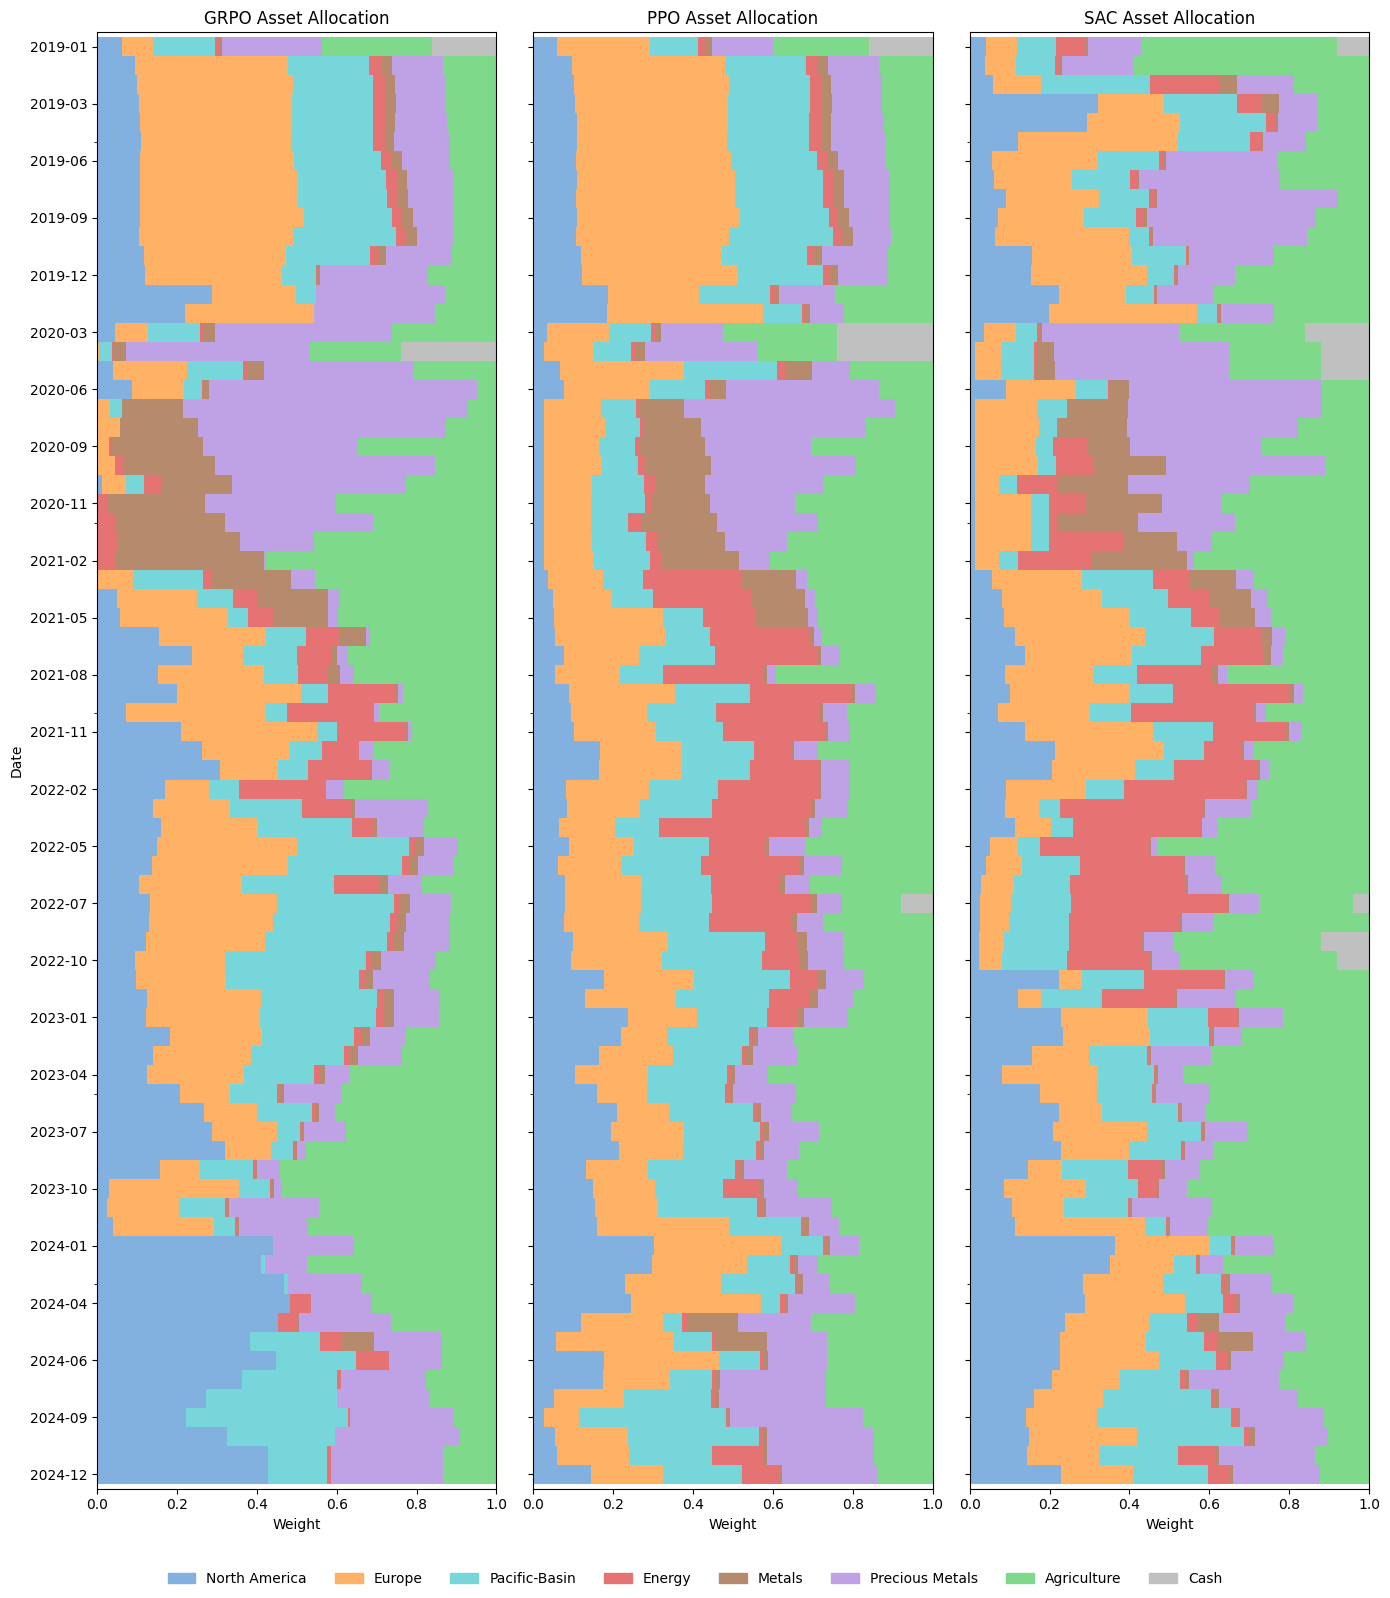

In [52]:
def plot_rotated_asset_allocation_with_fixed_ticks(grpo_df, ppo_df, sac_df):
    """
    날짜 축 문자열 변환 오류 수정 + 사용자 지정 색상 + 하단 범례 포함
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 16), sharey=True)

    models = ['GRPO', 'PPO', 'SAC']
    dataframes = [grpo_df, ppo_df, sac_df]

    # # 사용자 정의 색상 (부드러운 pastel 기반)
    # custom_colors = [
    #     "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
    #     "#a6d854", "#ffd92f"
    # ]
    # color_map = dict(zip(grpo_df.columns, custom_colors))
    color_map = {
        # --- Regional Equity Groups ---
        'North America': '#82B1E0',    # 연한 파랑 (북미)
        'Europe': '#FFB266',           # 부드러운 주황 (유럽)
        'Pacific-Basin': '#77D6D9',    # 연한 청록 (태평양권)

        # --- Commodity Groups ---
        'Energy': '#E57373',           # 밝은 붉은색 (에너지)
        'Metals': '#B68A6D',           # 부드러운 갈색 (산업금속)
        'Precious Metals': '#BFA2E5',  # 연보라 (귀금속)
        'Agriculture': '#7ED98A',      # 파스텔 초록 (농산물)

        # --- Cash / Neutral ---
        'Cash': '#C0C0C0'              # 밝은 회색 (현금)
    }

    for i, (df, ax) in enumerate(zip(dataframes, axes)):
        df_rev = df[::-1]
        df_rev.plot.barh(
            stacked=True,
            ax=ax,
            width=1.0,
            linewidth=0,
            color=[color_map[c] for c in df.columns],
            legend=False
        )
        ax.set_title(f'{models[i]} Asset Allocation', loc='center')
        ax.set_xlabel('Weight')
        ax.set_xlim(0, 1)
        ax.set_ylabel('Date')

        tick_interval = max(1, len(df) // 20)
        yticks = list(range(0, len(df), tick_interval))
        df.index = pd.to_datetime(df.index)
        yticklabels = [df.index[::-1][j].strftime("%Y-%m") for j in yticks]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

    # 아래 범례
    handles = [
        plt.matplotlib.patches.Patch(color=color_map[c], label=c)
        for c in grpo_df.columns
    ]
    fig.legend(handles=handles, loc='lower center', ncol=len(grpo_df.columns), fontsize='medium', frameon=False)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    
    plt.savefig("./figure/asset_allocation.png",  transparent=True, dpi=600, bbox_inches='tight')
    plt.show()

# 실행
plot_rotated_asset_allocation_with_fixed_ticks(
    final_grpo_weights_with_cash,
    final_ppo_weights_with_cash,
    final_sac_weights_with_cash
)


In [45]:
# 선택 개수 총합으로 나눠서 평균 비율로 만들고 싶으면:
total_counts = selection_df.sum(axis=1)
final_weight = final_weight.div(total_counts, axis=0)

# NaN → 0으로 채워 깔끔하게
final_weight = final_weight.fillna(0)

NameError: name 'selection_df' is not defined

In [46]:
def get_selected_group_weights(
    selected_strategies_df: pd.DataFrame,
    strategy_grouped_weights: dict
) -> pd.DataFrame:
    """
    선택된 전략에 따라 해당 전략의 자산군 weight를 추출하여 통합된 DataFrame을 반환

    Parameters:
    - selected_strategies_df: 전략 선택 테이블 (0 또는 1 값만 가짐)
    - strategy_grouped_weights: 전략 이름 → 자산군별 weight DataFrame (dict)

    Returns:
    - DataFrame: 선택된 전략 기준의 자산군별 weight 시계열
    """
    result = []

    for date, row in selected_strategies_df.iterrows():
        selected = row[row == 1.0]
        if selected.empty:
            continue  # 선택된 전략 없음
        strategy = selected.index[0]
        strategy_weights = strategy_grouped_weights[strategy]

        if date in strategy_weights.index:
            selected_row = strategy_weights.loc[date].copy()
            selected_row.name = date
            result.append(selected_row)
        else:
            print(f"[경고] {strategy} 전략에서 {date} 없음. 생략됨.")

    return pd.DataFrame(result)

In [48]:
grpo_best_weight_rebal

,risk_parity,min_var,max_sharpe,paa
2019-01-02,0.0,1.0,0.0,0.0
2019-01-31,1.0,0.0,0.0,0.0
2019-03-01,1.0,0.0,0.0,0.0
2019-03-29,1.0,0.0,0.0,0.0
2019-04-29,1.0,0.0,0.0,0.0
...,...,...,...,...
2024-08-23,0.0,0.0,1.0,0.0
2024-09-23,0.0,0.0,1.0,0.0
2024-10-21,0.0,0.0,1.0,0.0
2024-11-18,0.0,0.0,1.0,0.0


In [49]:
final_grpo_weights = get_selected_group_weights(grpo_best_weight_rebal, strategy_grouped_weights)

final_ppo_weights = get_selected_group_weights(ppo_best_weight_rebal, strategy_grouped_weights)
final_sac_weights = get_selected_group_weights(sac_best_weight_rebal, strategy_grouped_weights)

In [59]:
grpo_best_weight_rebal

,risk_parity,min_var,max_sharpe,paa
2019-01-02,0.0,1.0,0.0,0.0
2019-01-31,1.0,0.0,0.0,0.0
2019-03-01,1.0,0.0,0.0,0.0
2019-03-29,1.0,0.0,0.0,0.0
2019-04-29,1.0,0.0,0.0,0.0
...,...,...,...,...
2024-08-23,0.0,0.0,1.0,0.0
2024-09-23,0.0,0.0,1.0,0.0
2024-10-21,0.0,0.0,1.0,0.0
2024-11-18,0.0,0.0,1.0,0.0


In [50]:
def add_cash_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    각 행의 weight 합이 1이 안 되는 경우, 남은 비중을 'Cash' 열로 추가한다.

    Parameters:
    - df: 자산군별 weight DataFrame

    Returns:
    - df_with_cash: 'Cash' 열이 추가된 DataFrame
    """
    df_with_cash = df.copy()
    total_weight = df_with_cash.sum(axis=1)
    df_with_cash["Cash"] = 1.0 - total_weight
    return df_with_cash


In [51]:
final_ppo_weights_with_cash = add_cash_column(final_ppo_weights)
final_sac_weights_with_cash = add_cash_column(final_sac_weights)
final_grpo_weights_with_cash = add_cash_column(final_grpo_weights)


In [52]:
final_grpo_weights_with_cash.sum(axis=1)

2019-01-02    1.0
2019-01-31    1.0
2019-03-01    1.0
2019-03-29    1.0
2019-04-29    1.0
             ... 
2024-08-23    1.0
2024-09-23    1.0
2024-10-21    1.0
2024-11-18    1.0
2024-12-17    1.0
Length: 76, dtype: float64

In [49]:
# final_ppo_weights_with_cash.to_csv("final_ppo_weights_with_cash.csv")
# final_sac_weights_with_cash.to_csv("final_sac_weights_with_cash.csv")
# final_grpo_weights_with_cash.to_csv("final_grpo_weights_with_cash.csv")

In [56]:
final_ppo_weights_with_cash = pd.read_csv("final_ppo_weights_with_cash.csv", index_col=0)
final_sac_weights_with_cash = pd.read_csv("final_sac_weights_with_cash.csv", index_col=0)
final_grpo_weights_with_cash = pd.read_csv("final_grpo_weights_with_cash.csv", index_col=0)

In [58]:
final_grpo_weights_with_cash

,Energy,Metals,Precious Metals,Agriculture,Developed Equity,Emerging Equity,Cash
2019-01-02,1.762334e-02,-5.822419e-18,0.359271,2.064209e-01,0.212482,0.180218,0.023985
2019-01-31,3.090662e-02,2.581975e-02,0.127617,9.039370e-02,0.591637,0.090379,0.043247
2019-03-01,2.972589e-02,2.528156e-02,0.127495,8.470697e-02,0.602274,0.089282,0.041234
2019-03-29,3.032965e-02,2.546218e-02,0.125654,8.643516e-02,0.602401,0.089435,0.040283
2019-04-29,3.009076e-02,2.425034e-02,0.131777,8.324675e-02,0.601423,0.089429,0.039783
...,...,...,...,...,...,...,...
2024-08-23,4.424911e-16,2.301516e-17,0.231890,5.587939e-16,0.272529,0.328776,0.166804
2024-09-23,6.324252e-03,1.354544e-17,0.258903,9.226105e-17,0.222158,0.405875,0.106740
2024-10-21,2.193904e-16,2.190028e-18,0.313264,7.809986e-17,0.324430,0.271146,0.091161
2024-11-18,9.712900e-03,1.568372e-17,0.282433,1.707229e-16,0.484525,0.090800,0.132529


In [50]:
grpo_best_weight_rebal.index = grpo_best_weight_rebal.index.strftime('%Y-%m-%d')
ppo_best_weight_rebal.index = ppo_best_weight_rebal.index.strftime('%Y-%m-%d')
sac_best_weight_rebal.index = sac_best_weight_rebal.index.strftime('%Y-%m-%d')

In [51]:
rename_col = {"risk_parity" : "Risk Parity",
 "min_var" : "Min Var",
 "max_sharpe" : "Max Sharpe",
 "paa" : "PAA"
}
grpo_best_weight_rebal.rename(columns=rename_col, inplace=True)
ppo_best_weight_rebal.rename(columns=rename_col, inplace=True)
sac_best_weight_rebal.rename(columns=rename_col, inplace=True)

In [52]:
grpo_best_weight_rebal

,Risk Parity,Min Var,Max Sharpe,PAA
2019-01-02,0.0,1.0,0.0,0.0
2019-01-31,1.0,0.0,0.0,0.0
2019-03-01,1.0,0.0,0.0,0.0
2019-03-29,1.0,0.0,0.0,0.0
2019-04-29,1.0,0.0,0.0,0.0
...,...,...,...,...
2024-08-23,0.0,0.0,1.0,0.0
2024-09-23,0.0,0.0,1.0,0.0
2024-10-21,0.0,0.0,1.0,0.0
2024-11-18,0.0,0.0,1.0,0.0


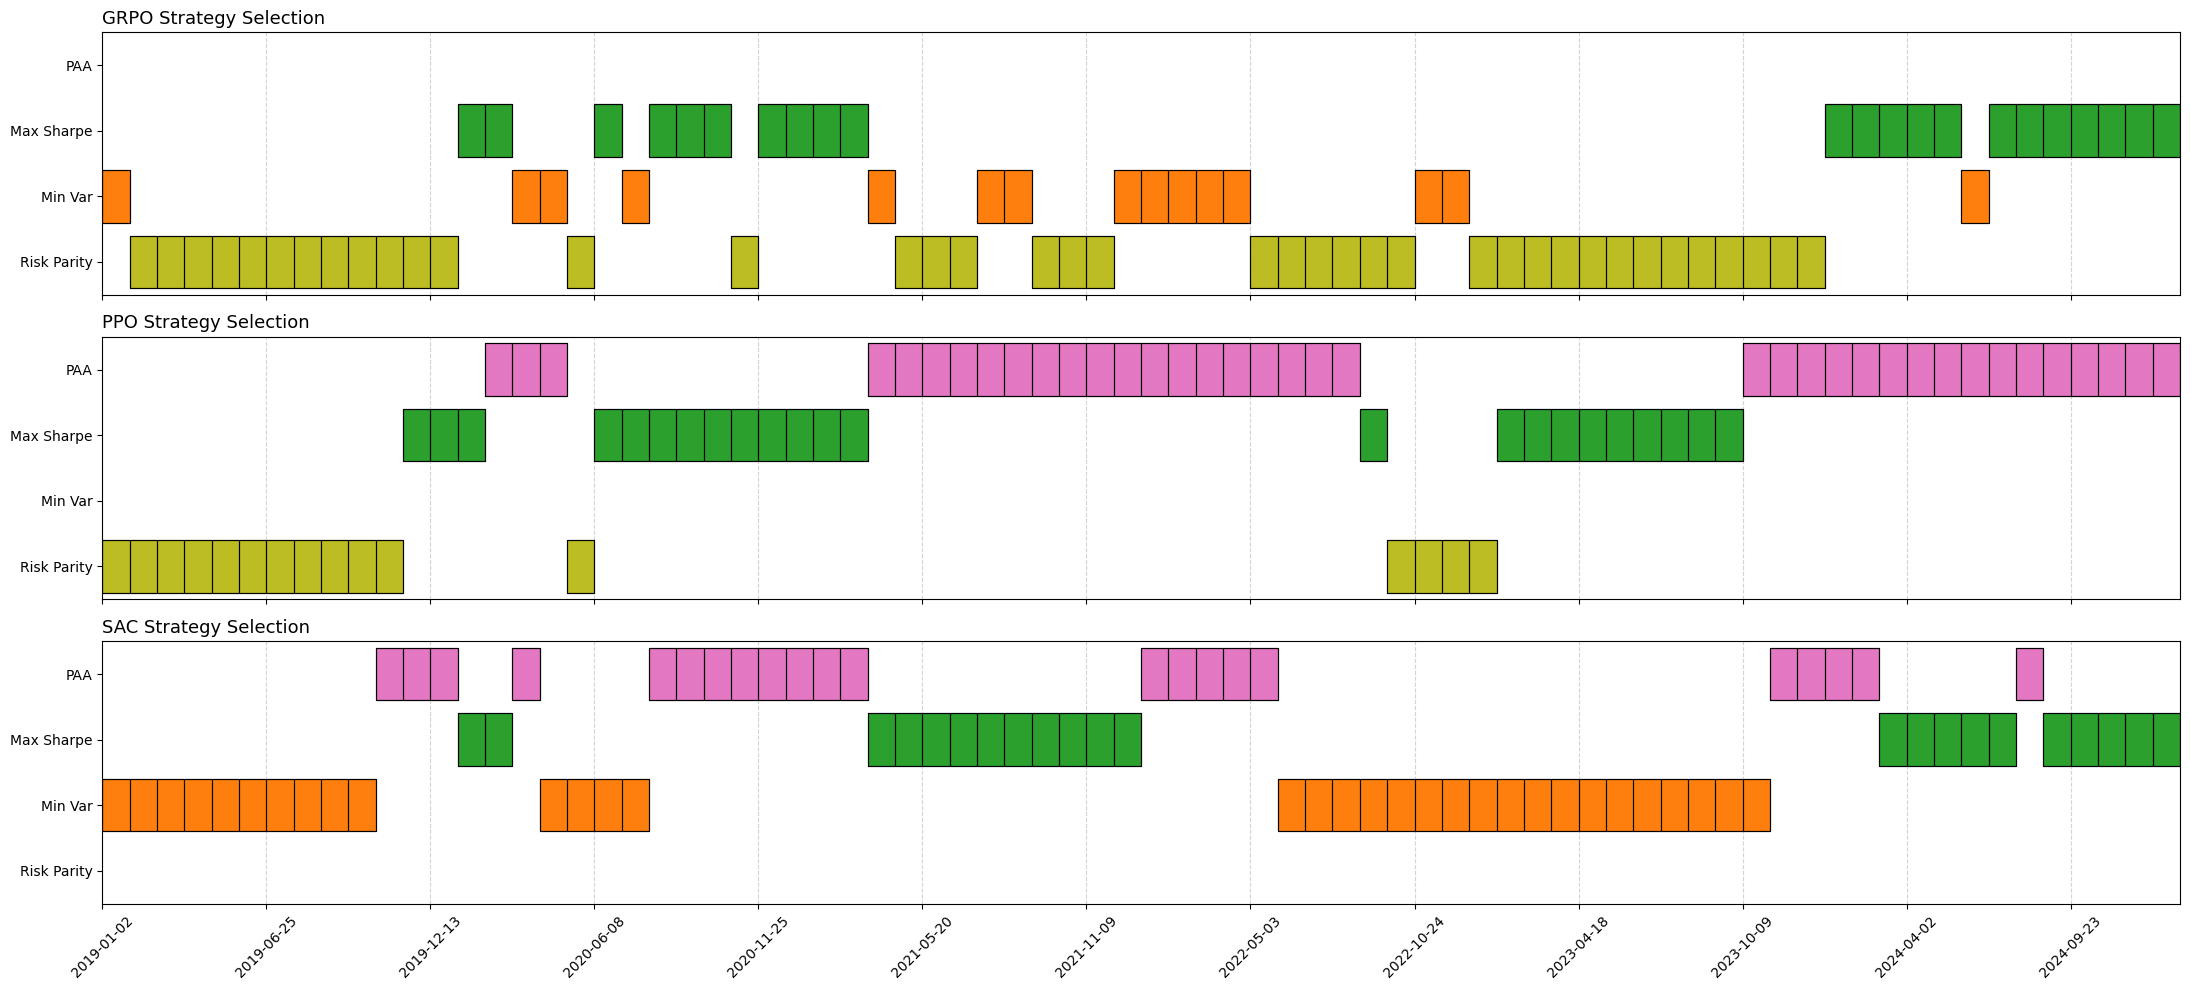

In [53]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

rebal_dict = {
    "GRPO": grpo_best_weight_rebal,
    "PPO": ppo_best_weight_rebal,
    "SAC": sac_best_weight_rebal
}

color_map = {
    'Risk Parity': '#bcbd22',
    'Min Var': '#ff7f0e',
    'Max Sharpe': '#2ca02c',
    'PAA': '#e377c2',
}
all_strats = ['Risk Parity', 'Min Var', 'Max Sharpe', 'PAA']
y_pos = {s: i for i, s in enumerate(all_strats)}

# 공통 인덱스
base_index = max(rebal_dict.values(), key=lambda df: len(df)).index
xN = len(base_index)

def ensure_cols(df, cols):
    df = df.reindex(base_index).copy()
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    return df[cols].fillna(0)

def mask_to_spans(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    if idx.size == 0: return []
    cuts = np.where(np.diff(idx) != 1)[0] + 1
    groups = np.split(idx, cuts)
    return [(g[0], len(g)) for g in groups]

rebal_dict = {k: ensure_cols(v, all_strats) for k, v in rebal_dict.items()}

fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

step = 6
xticks = np.arange(0, xN, step)
xticklabels = base_index[::step]

for ax, (label, df) in zip(axes, rebal_dict.items()):
    # xtick 세로줄
    for xpos in xticks:
        ax.axvline(x=xpos, color='lightgray', linestyle='--', linewidth=0.8, zorder=0)

    for strat in all_strats:
        mask = df[strat].to_numpy() == 1.0
        y0 = y_pos[strat] - 0.4
        h  = 0.8

        # 1) 연속 구간 채우기
        for start, length in mask_to_spans(mask):
            ax.broken_barh([(start, length)], (y0, h),
                           facecolors=color_map[strat],
                           edgecolors='black', linewidth=0.8, zorder=1)

            # 2) 구간 내부를 폭=1 단위 네모칸으로 분할(경계선만)
            for k in range(start, start + length):
                ax.add_patch(
                    Rectangle((k, y0), 1, h,
                              fill=False, edgecolor='black', linewidth=0.8, zorder=2)
                )

    ax.set_title(f"{label} Strategy Selection", loc='left', fontsize=13)
    ax.set_yticks(range(len(all_strats)))
    ax.set_yticklabels(all_strats)
    ax.set_ylim(-0.5, len(all_strats) - 0.5)
    ax.set_xlim(0, xN)

# x축 라벨
axes[-1].set_xticks(xticks)
axes[-1].set_xticklabels(xticklabels, rotation=45)

plt.tight_layout()
plt.savefig("./figure/strategy_selection_bar_chart.png", dpi=300)
plt.show()


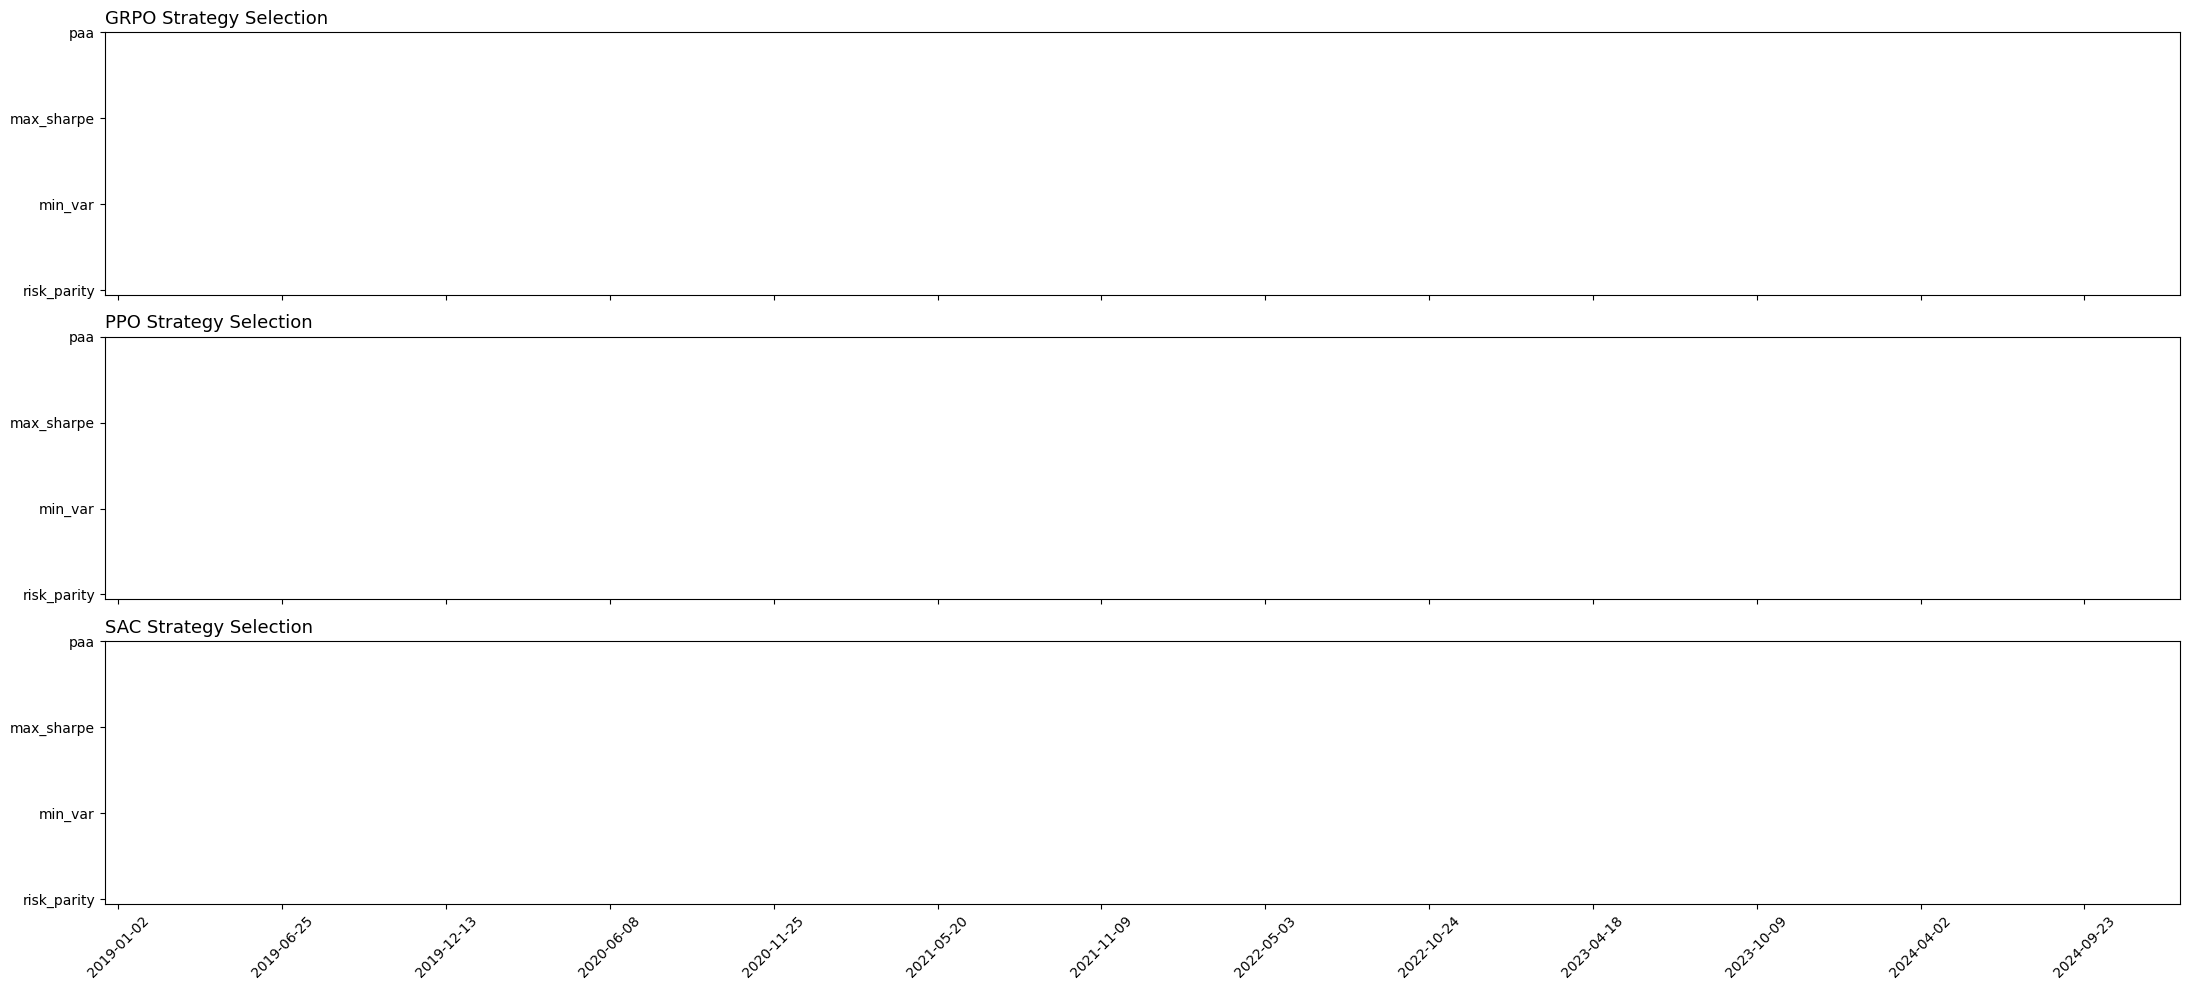

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

rebal_dict = {
    "GRPO": grpo_best_weight_rebal,
    "PPO": ppo_best_weight_rebal,
    "SAC": sac_best_weight_rebal
}

color_map = {
    'risk_parity': '#bcbd22',
    'min_var': '#ff7f0e',
    'max_sharpe': '#2ca02c',
    'paa': '#e377c2',
}

fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

# 기준이 될 x축 범위 계산
max_len = max(len(df) for df in rebal_dict.values())
x = range(max_len)

# x축 라벨용 날짜 (가장 긴 DF 기준)
base_df = max(rebal_dict.values(), key=lambda df: len(df))
# date_str = base_df.index.strftime('%Y-%m')
date_str = base_df.index

for ax, (label, df) in zip(axes, rebal_dict.items()):
    df = df.copy().reset_index(drop=True)

    for i, strat in enumerate(['risk_parity', 'min_var', 'max_sharpe', 'paa']):
        y = i
        strat_mask = (df[strat] == 1.0) if strat in df.columns else pd.Series([False] * len(df))
        ax.bar(
            x=pd.Series(x)[strat_mask],
            height=0.8,
            width=1.0,
            bottom=y,
            color=color_map[strat],
            edgecolor='black',
            align='center'
        )

    ax.set_title(f"{label} Strategy Selection", loc='left', fontsize=13)
    ax.set_yticks(range(4))
    ax.set_yticklabels(['risk_parity', 'min_var', 'max_sharpe', 'paa'])

    # x축 설정
    ax.set_xticks(list(x)[::6])
    ax.set_xticklabels(date_str[::6], rotation=45)

    # ✅ 양 끝 잘림 방지: x축 범위 여유 주기
    ax.set_xlim(-0.5, max_len - 0.5)

plt.tight_layout()
# plt.savefig("./figure/strategy_selection_bar_chart.png", dpi=300)
plt.show()


In [55]:
# 모든 자산군 weight를 0 이상으로 클리핑
final_grpo_weights_with_cash = final_grpo_weights_with_cash.clip(lower=0)
final_ppo_weights_with_cash = final_ppo_weights_with_cash.clip(lower=0)
final_sac_weights_with_cash = final_sac_weights_with_cash.clip(lower=0)



In [58]:
final_grpo_weights_with_cash

,North America,Europe,Pacific-Basin,Energy,Metals,Precious Metals,Agriculture,Cash
2019-01-02,0.104567,0.000000e+00,0.288133,1.762334e-02,0.000000e+00,0.359271,0.230406,0.000000e+00
2019-01-31,0.095841,3.835132e-01,0.202662,3.090662e-02,2.581975e-02,0.127617,0.133640,0.000000e+00
2019-03-01,0.101042,3.895587e-01,0.200956,2.972589e-02,2.528156e-02,0.127495,0.125941,0.000000e+00
2019-03-29,0.104219,3.829864e-01,0.204630,3.032965e-02,2.546218e-02,0.125654,0.126718,0.000000e+00
2019-04-29,0.108522,3.788973e-01,0.203434,3.009076e-02,2.425034e-02,0.131777,0.123030,0.000000e+00
...,...,...,...,...,...,...,...,...
2024-08-23,0.272529,2.344476e-16,0.328776,4.424911e-16,2.301516e-17,0.231890,0.166804,0.000000e+00
2024-09-23,0.222158,1.903233e-16,0.405875,6.324252e-03,1.354544e-17,0.258903,0.106740,1.110223e-16
2024-10-21,0.324430,1.848877e-16,0.271146,2.193904e-16,2.190028e-18,0.313264,0.091161,0.000000e+00
2024-11-18,0.427287,4.148634e-16,0.148038,9.712900e-03,1.568372e-17,0.282433,0.132529,0.000000e+00


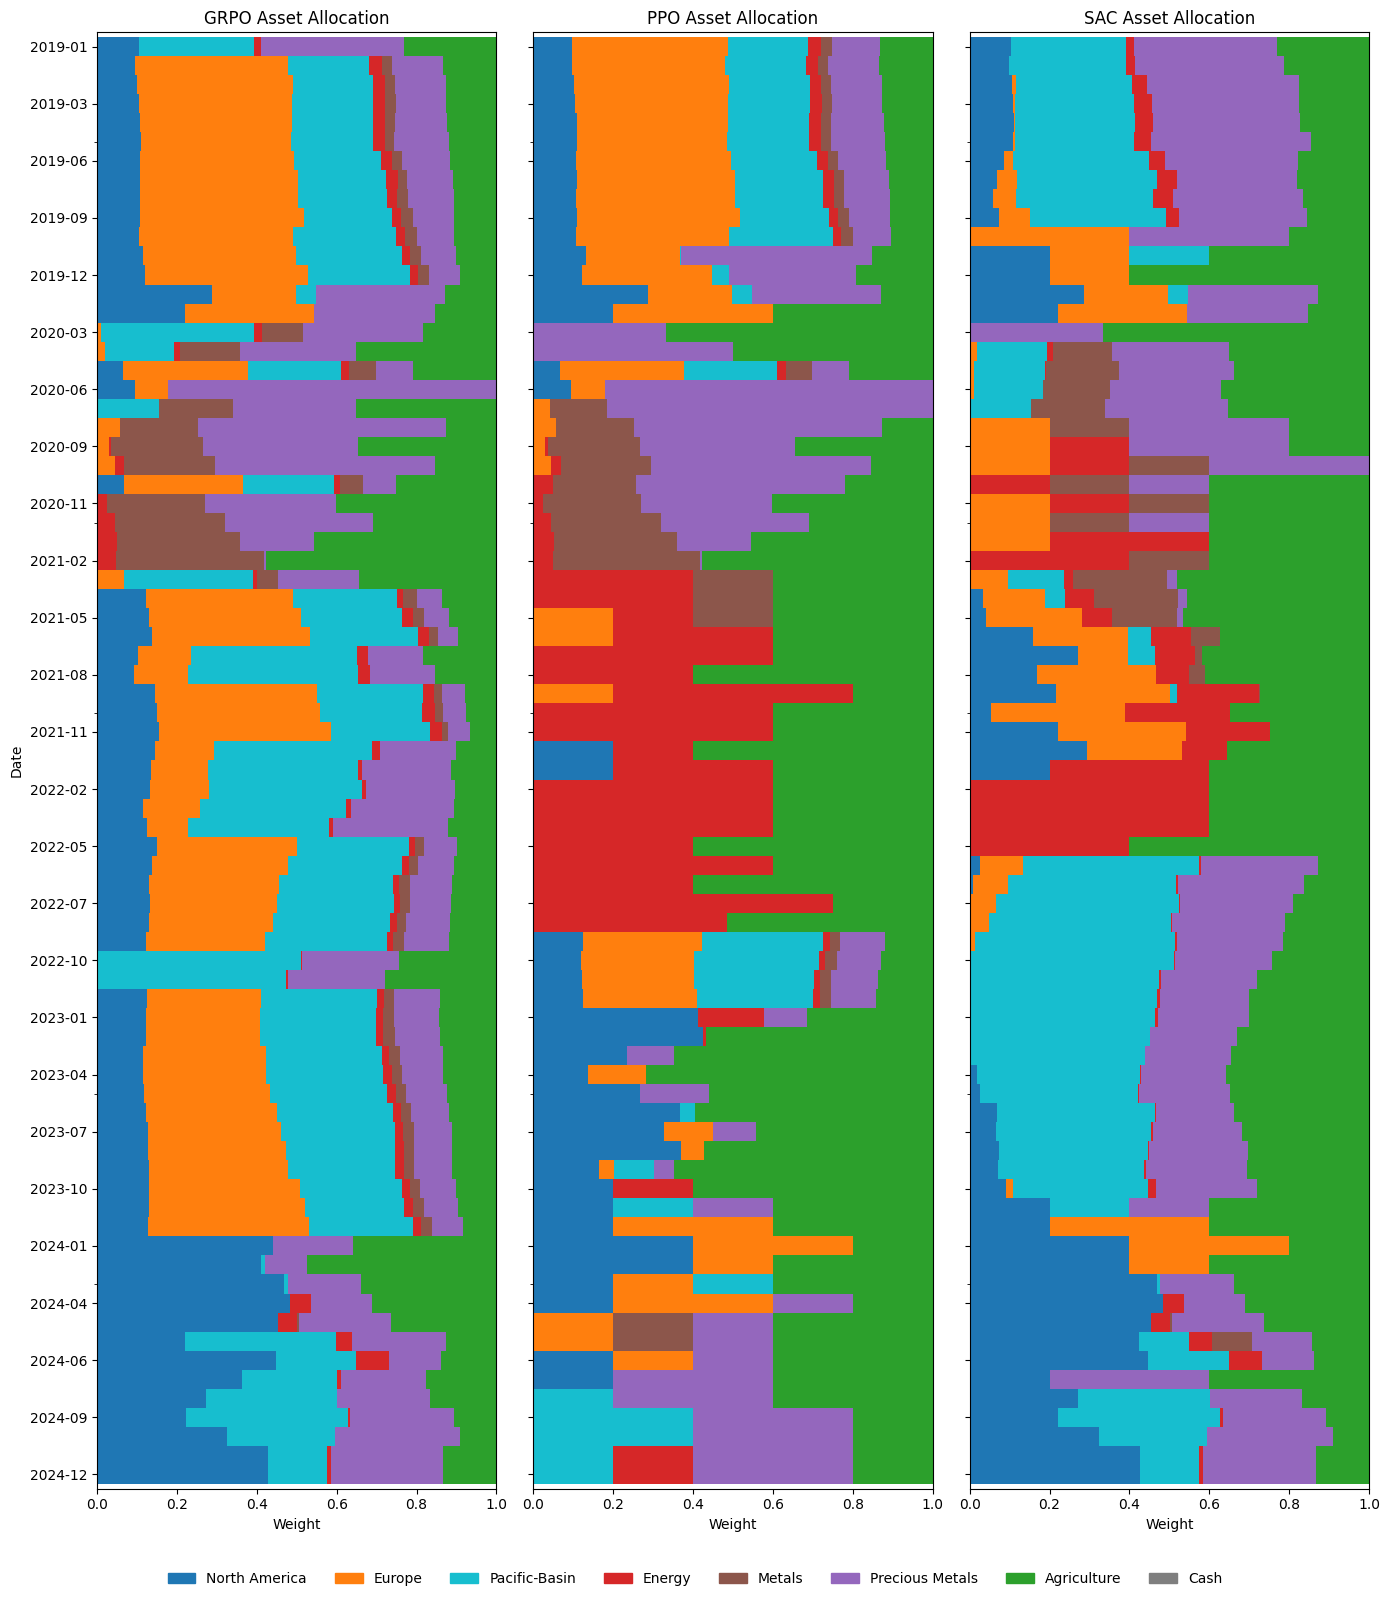

In [56]:
def plot_rotated_asset_allocation_with_fixed_ticks(grpo_df, ppo_df, sac_df):
    """
    날짜 축 문자열 변환 오류 수정 + 사용자 지정 색상 + 하단 범례 포함
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 16), sharey=True)

    models = ['GRPO', 'PPO', 'SAC']
    dataframes = [grpo_df, ppo_df, sac_df]

    # # 사용자 정의 색상 (부드러운 pastel 기반)
    # custom_colors = [
    #     "#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3",
    #     "#a6d854", "#ffd92f"
    # ]
    # color_map = dict(zip(grpo_df.columns, custom_colors))
    color_map = {
        # --- Regional Equity Groups ---
        'North America': '#1f77b4',    # 선명한 파랑 (북미)
        'Europe': '#ff7f0e',           # 주황색 (유럽)
        'Pacific-Basin': '#17becf',    # 청록색 (태평양권)

        # --- Commodity Groups ---
        'Energy': '#d62728',           # 강한 빨강 (에너지)
        'Metals': '#8c564b',           # 갈색 (산업금속)
        'Precious Metals': '#9467bd',  # 보라색 (귀금속)
        'Agriculture': '#2ca02c',      # 선명한 초록 (농산물)

        # --- Cash / Neutral ---
        'Cash': '#7f7f7f'              # 진한 회색 (현금)
    }

    for i, (df, ax) in enumerate(zip(dataframes, axes)):
        df_rev = df[::-1]
        df_rev.plot.barh(
            stacked=True,
            ax=ax,
            width=1.0,
            linewidth=0,
            color=[color_map[c] for c in df.columns],
            legend=False
        )
        ax.set_title(f'{models[i]} Asset Allocation', loc='center')
        ax.set_xlabel('Weight')
        ax.set_xlim(0, 1)
        ax.set_ylabel('Date')

        tick_interval = max(1, len(df) // 20)
        yticks = list(range(0, len(df), tick_interval))
        df.index = pd.to_datetime(df.index)
        yticklabels = [df.index[::-1][j].strftime("%Y-%m") for j in yticks]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

    # 아래 범례
    handles = [
        plt.matplotlib.patches.Patch(color=color_map[c], label=c)
        for c in grpo_df.columns
    ]
    fig.legend(handles=handles, loc='lower center', ncol=len(grpo_df.columns), fontsize='medium', frameon=False)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    
    # plt.savefig("./figure/asset_allocation.png", dpi=300, bbox_inches='tight')
    plt.show()

# 실행
plot_rotated_asset_allocation_with_fixed_ticks(
    final_grpo_weights_with_cash,
    final_ppo_weights_with_cash,
    final_sac_weights_with_cash
)


In [66]:
final_grpo_weights_with_cash

,Energy,Metals,Precious Metals,Agriculture,Developed Equity,Emerging Equity,Cash
2019-01-02,0.000000,0.000000e+00,0.333333,3.333333e-01,0.000000,0.000000,0.333333
2019-01-31,0.030907,2.581975e-02,0.127617,9.039370e-02,0.591637,0.090379,0.043247
2019-03-01,0.029726,2.528156e-02,0.127495,8.470697e-02,0.602274,0.089282,0.041234
2019-03-29,0.044382,-2.844586e-18,0.369219,1.528692e-01,0.222369,0.189416,0.021745
2019-04-29,0.044076,-8.783448e-18,0.368456,1.495376e-01,0.228117,0.186710,0.023103
...,...,...,...,...,...,...,...
2024-08-23,0.000000,0.000000e+00,0.400000,0.000000e+00,0.000000,0.200000,0.400000
2024-09-23,0.000000,0.000000e+00,0.400000,0.000000e+00,0.200000,0.200000,0.200000
2024-10-21,0.000000,0.000000e+00,0.400000,0.000000e+00,0.200000,0.200000,0.200000
2024-11-18,0.009713,1.568372e-17,0.282433,1.707229e-16,0.484525,0.090800,0.132529


In [ ]:
imp = total_df[["equal_strategy", "equal_asset_weight"]]

In [ ]:
imp.to_csv("./portfolio_price_discrete_rebal_step_1m_concat_asset/result/equal_strategy.csv")